# GAN - Queremos o Gerador

Tens duas redes:

- `Gerador (G):` recebe ruído aleatório e cria imagens falsas

- `Discriminador (D):` recebe imagens e tenta dizer se são reais ou falsas

Durante o treino, em cada batch, as imagens circulam assim:

1. um batch de imagens reais vai para o discriminador

2. um batch de ruído aleatório vai para o gerador

3. o gerador produz imagens falsas

4. essas imagens falsas também vão para o discriminador

5. primeiro atualizas o discriminador

6. depois atualizas o gerador

In [ ]:
print("teste")

teste


In [ ]:
import os

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import save_image, make_grid

from wiki_gan_dataset import build_wiki_gan_dataloader, get_dcgan_transform

## Configuração

In [ ]:
# =========================================================
# Configuração
# =========================================================
REAL_DIR = "../deepfake_data/wiki"
OUTPUT_DIR = "outputs"
SAMPLES_DIR = os.path.join(OUTPUT_DIR, "samples")
CHECKPOINTS_DIR = os.path.join(OUTPUT_DIR, "checkpoints")

IMAGE_SIZE = 64
BATCH_SIZE = 64
LATENT_DIM = 100    # Tamanho do vetor aleatório que entra no gerador
NGF = 64    # Número base de filtros do gerador
NDF = 64    # Número base de filtros do discriminador
NUM_CHANNELS = 3    # 3 channels porque estou a usar RGB

# Parametros de treino
NUM_EPOCHS = 300
LR_G = 2e-4     # Learning rate do gerador
LR_D = 1e-4     # Learning rate do discriminador
BETA1 = 0.5     # Hiperparametro do Adam (é um valor clássico em DCGAN)
SEED = 42
NUM_WORKERS = 2     # Número de workers no DataLoader

# Que folds usar
START_FOLD = 0
END_FOLD = 5
INTERVAL = True

# Usar CUDA para ser mais rápido
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

# Crias as pastas dos outputs
os.makedirs(SAMPLES_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

# Torna o treino mais consistente entre execuções
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Device:", DEVICE)

Device: cuda


## Dataset e DataLoader

In [ ]:
transform = get_dcgan_transform(image_size=IMAGE_SIZE)

dataset, dataloader = build_wiki_gan_dataloader(
    img_dir=REAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    range_folds=(START_FOLD, END_FOLD),
    interval=INTERVAL,
    shuffle=True,
    drop_last=True,
)

print(f"Total de imagens reais: {len(dataset)}")
print(f"Folds usados: {dataset.fold_names}")

Total de imagens reais: 1467
Folds usados: ['00', '01', '02', '03', '04']


### Ver uma imagem do dataset

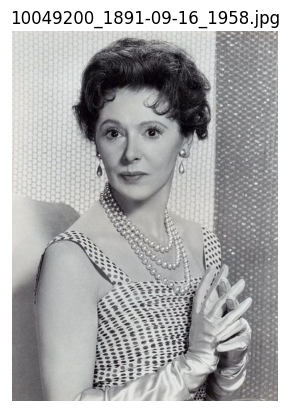

In [5]:
dataset.show(0)

### Inicialização de pesos

In [ ]:
# Esta função inicializa os pesos da rede, se for:
# - Camada convolucional: inicializa os pesos com distribuição normal (média 0 e desvio padrão 0.02)
# - Camada BatchNorm: pesos perto de 1 e bias 0 
def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)
# Isto é o tipo de inicialização clássica em DCGAN

# Gerador

In [ ]:
# O Gerador recebe um vetor aleatório z e tenta convertê-lo numa imagem falsa realista
class Generator(nn.Module):
    def __init__(self, latent_dim=100, ngf=64, nc=3):
        super().__init__()

        self.init = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
        )

        self.main = nn.Sequential(
            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf * 8, ngf * 4, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf * 4, ngf * 2, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf * 2, ngf, 3, 1, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2, mode="nearest"),
            nn.Conv2d(ngf, nc, 3, 1, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.init(z)
        return self.main(x)

# Discriminador

In [ ]:
# Recebe uma imagem e tenta dizer se ela é real ou falsa
# Ele faz o oposto do gerador, reduz progressivamente a resolução, aumentando profundidade e no fim produz um único valor por imagem
class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super().__init__()
        self.main = nn.Sequential(
            # 64x64 -> 32x32
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32 -> 16x16
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            # 16x16 -> 8x8
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            # 8x8 -> 4x4
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            # 4x4 -> 1x1
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.main(x).view(-1)

# Instanciar modelos

In [9]:
netG = Generator(LATENT_DIM, NGF, NUM_CHANNELS).to(DEVICE)
netD = Discriminator(NUM_CHANNELS, NDF).to(DEVICE)

netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)

Generator(
  (init): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (main): Sequential(
    (0): Upsample(scale_factor=2.0, mode='nearest')
    (1): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU(inplace=True)
    (4): Upsample(scale_factor=2.0, mode='nearest')
    (5): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): Upsample(scale_factor=2.0, mode='nearest')
    (9): Conv2d(128, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats

In [ ]:
# Loss binária com logits
# O discriminador devolve logits crus, sem sigmoid, esta loss combina sigmoid e binary cross entropy de forma mais estavel numericamente
criterion = nn.BCEWithLogitsLoss()

# Otimizadores Adam para o discriminador e o gerador
optimizerD = optim.Adam(netD.parameters(), lr=LR_D, betas=(BETA1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=LR_G, betas=(BETA1, 0.999))

# Ruido fixo para as amostras. Este ruido serve para gerar sempre as mesmas 64 imagens ao longo do treino.
# Deste modo podemos ver a evolução do gerador de forma consistente (na epoch 1, 10, 50, etc)
fixed_noise = torch.randn(64, LATENT_DIM, 1, 1, device=DEVICE)

## Função para guardar amostras

In [11]:
def save_generated_samples(epoch, generator, noise):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(noise).detach().cpu()
        fake_images = (fake_images + 1) / 2  # [-1,1] -> [0,1]
        grid = make_grid(fake_images, nrow=8, padding=2, normalize=False)
        save_image(grid, os.path.join(SAMPLES_DIR, f"epoch_{epoch:03d}.png"))
    generator.train()

## Treino

In [12]:
import pandas as pd
history = []
g_losses = []
d_losses = []

print("A começar treino...")

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    epoch_dx = 0.0
    epoch_dgz_fake = 0.0
    epoch_dgz_gen = 0.0

    for i, real_images in enumerate(dataloader):
        real_images = real_images.to(DEVICE)
        b_size = real_images.size(0)

        # -----------------------------------------
        # 1. Treinar Discriminador
        # -----------------------------------------
        netD.zero_grad(set_to_none=True)

        labels_real = torch.ones(b_size, device=DEVICE)
        output_real = netD(real_images)
        lossD_real = criterion(output_real, labels_real)

        noise = torch.randn(b_size, LATENT_DIM, 1, 1, device=DEVICE)
        fake_images = netG(noise)

        labels_fake = torch.zeros(b_size, device=DEVICE)
        output_fake = netD(fake_images.detach())
        lossD_fake = criterion(output_fake, labels_fake)

        lossD = lossD_real + lossD_fake
        lossD.backward()
        optimizerD.step()

        # -----------------------------------------
        # 2. Treinar Gerador
        # -----------------------------------------
        netG.zero_grad(set_to_none=True)

        labels_gen = torch.ones(b_size, device=DEVICE)
        output_gen = netD(fake_images)
        lossG = criterion(output_gen, labels_gen)
        lossG.backward()
        optimizerG.step()

        epoch_d_loss += lossD.item()
        epoch_g_loss += lossG.item()

        epoch_dx += torch.sigmoid(output_real).mean().item()
        epoch_dgz_fake += torch.sigmoid(output_fake).mean().item()
        epoch_dgz_gen += torch.sigmoid(output_gen).mean().item()

        if i % 50 == 0:
            print(
                f"[Epoch {epoch}/{NUM_EPOCHS}] "
                f"[Batch {i}/{len(dataloader)}] "
                f"Loss_D: {lossD.item():.4f} "
                f"Loss_G: {lossG.item():.4f} "
                f"D(x): {torch.sigmoid(output_real).mean().item():.4f} "
                f"D(G(z)): {torch.sigmoid(output_fake).mean().item():.4f}/"
                f"{torch.sigmoid(output_gen).mean().item():.4f}"
            )

    avg_d = epoch_d_loss / len(dataloader)
    avg_g = epoch_g_loss / len(dataloader)
    avg_dx = epoch_dx / len(dataloader)
    avg_dgz_fake = epoch_dgz_fake / len(dataloader)
    avg_dgz_gen = epoch_dgz_gen / len(dataloader)

    d_losses.append(avg_d)
    g_losses.append(avg_g)

    history.append({
        "epoch": epoch,
        "loss_d": avg_d,
        "loss_g": avg_g,
        "D_x": avg_dx,
        "D_G_z_fake": avg_dgz_fake,
        "D_G_z_gen": avg_dgz_gen,
    })

    print(
        f"==> Epoch {epoch}: "
        f"avg Loss_D={avg_d:.4f}, "
        f"avg Loss_G={avg_g:.4f}, "
        f"avg D(x)={avg_dx:.4f}, "
        f"avg D(G(z)) fake={avg_dgz_fake:.4f}, "
        f"avg D(G(z)) gen={avg_dgz_gen:.4f}"
    )

    save_generated_samples(epoch, netG, fixed_noise)

    history_df = pd.DataFrame(history)
    history_df.to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)

    torch.save({
        "epoch": epoch,
        "netG_state_dict": netG.state_dict(),
        "netD_state_dict": netD.state_dict(),
        "optimizerG_state_dict": optimizerG.state_dict(),
        "optimizerD_state_dict": optimizerD.state_dict(),
        "g_losses": g_losses,
        "d_losses": d_losses,
        "history": history,
        "folds_used": dataset.fold_names,
        "real_dir": REAL_DIR,
    }, os.path.join(CHECKPOINTS_DIR, f"dcgan_epoch_{epoch:03d}.pt"))

print("Treino terminado.")

A começar treino...
[Epoch 1/300] [Batch 0/22] Loss_D: 1.5238 Loss_G: 2.0222 D(x): 0.4603 D(G(z)): 0.3750/0.1820
==> Epoch 1: avg Loss_D=1.7835, avg Loss_G=4.8601, avg D(x)=0.5573, avg D(G(z)) fake=0.4900, avg D(G(z)) gen=0.0450
[Epoch 2/300] [Batch 0/22] Loss_D: 0.9360 Loss_G: 6.3687 D(x): 0.6393 D(G(z)): 0.1666/0.0034
==> Epoch 2: avg Loss_D=1.2822, avg Loss_G=6.1885, avg D(x)=0.6773, avg D(G(z)) fake=0.3446, avg D(G(z)) gen=0.0091
[Epoch 3/300] [Batch 0/22] Loss_D: 0.8511 Loss_G: 5.4144 D(x): 0.7883 D(G(z)): 0.3031/0.0193
==> Epoch 3: avg Loss_D=1.4931, avg Loss_G=4.1387, avg D(x)=0.6375, avg D(G(z)) fake=0.3734, avg D(G(z)) gen=0.0546
[Epoch 4/300] [Batch 0/22] Loss_D: 1.4910 Loss_G: 3.8927 D(x): 0.5582 D(G(z)): 0.3561/0.0626
==> Epoch 4: avg Loss_D=1.1700, avg Loss_G=3.5167, avg D(x)=0.6580, avg D(G(z)) fake=0.3335, avg D(G(z)) gen=0.0753
[Epoch 5/300] [Batch 0/22] Loss_D: 0.9478 Loss_G: 3.9105 D(x): 0.6548 D(G(z)): 0.2371/0.0441
==> Epoch 5: avg Loss_D=1.1198, avg Loss_G=2.7622, 

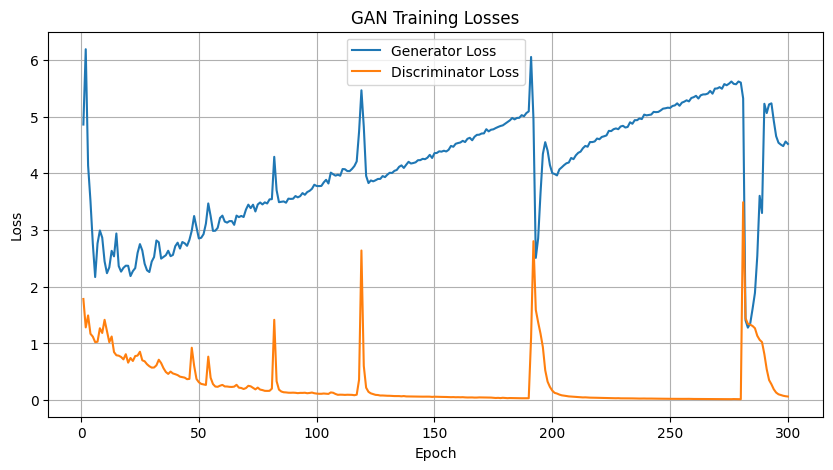

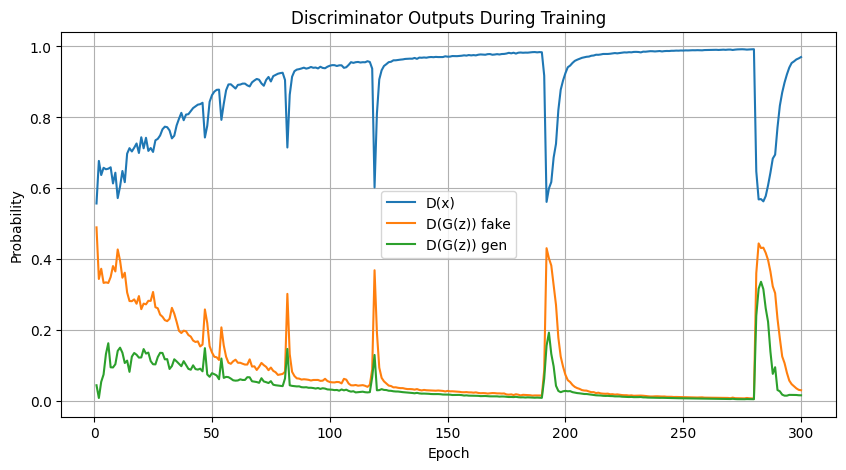

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt

history_path = os.path.join(OUTPUT_DIR, "training_history.csv")
history_df = pd.read_csv(history_path)

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["loss_g"], label="Generator Loss")
plt.plot(history_df["epoch"], history_df["loss_d"], label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Losses")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(history_df["epoch"], history_df["D_x"], label="D(x)")
plt.plot(history_df["epoch"], history_df["D_G_z_fake"], label="D(G(z)) fake")
plt.plot(history_df["epoch"], history_df["D_G_z_gen"], label="D(G(z)) gen")
plt.xlabel("Epoch")
plt.ylabel("Probability")
plt.title("Discriminator Outputs During Training")
plt.legend()
plt.grid(True)
plt.show()

Como o D devolve logits, aplicas sigmoid para obter algo parecido com probabilidade.

- `D(x):` Probabilidade média atribuída às imagens reais. (idealmente alta)

- `D(G(z)) fake:` Probabilidade média atribuída às falsas quando treinas o D. (idealmente baixa)

- `D(G(z)) gen:` Probabilidade média atribuída às falsas quando observadas no passo do G. (se começar a subir, pode indicar que o G está a enganar melhor o D)

# Gerar imagens a partir do último modelo em memória

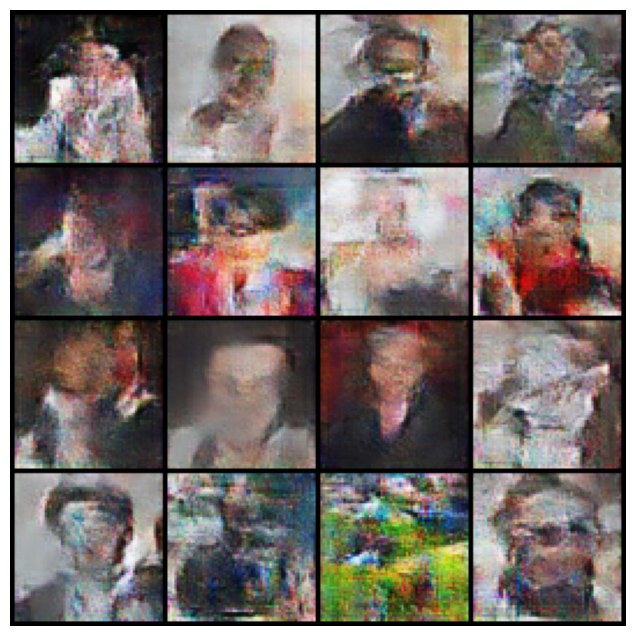

In [18]:
netG.eval()
with torch.no_grad():
    noise = torch.randn(16, LATENT_DIM, 1, 1, device=DEVICE)
    fake_images = netG(noise).cpu()
    fake_images = (fake_images + 1) / 2

grid = make_grid(fake_images, nrow=4, padding=2)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

# Confirmar que os dados estão bem:

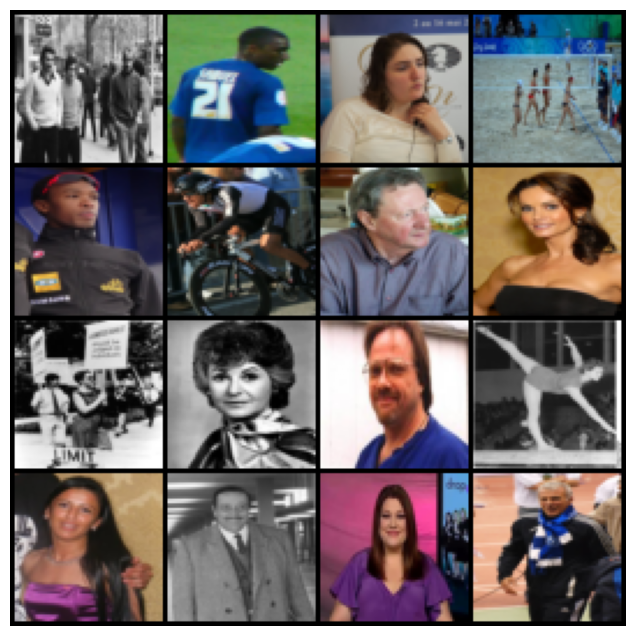

In [15]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

real_batch = next(iter(dataloader))
real_batch = real_batch[:16].cpu()
real_batch = (real_batch + 1) / 2  # volta de [-1,1] para [0,1]

grid = make_grid(real_batch, nrow=4, padding=2)
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.show()

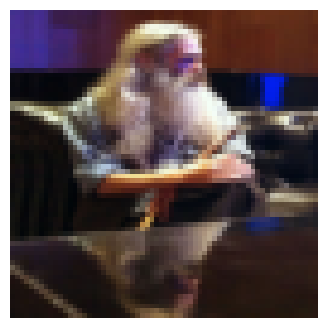

In [16]:
real_batch = next(iter(dataloader))
img = real_batch[0].cpu()
img = (img + 1) / 2  # [-1,1] -> [0,1]

import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.imshow(img.permute(1, 2, 0))
plt.axis("off")
plt.show()